# 01 · Exploratory data analysis (part 1: profile)

First look at the 9 raw Olist tables exactly as loaded: row counts, nulls, distinct counts,
date ranges, and the quirks that feed `docs/data_quality_log.md`.

**Source.** Reads the `raw` schema in Postgres via `scripts/db.py` (credentials from `.env`).
If Postgres isn't reachable it falls back to the CSVs in `data/raw/`; both are the same text data,
so every number below is identical either way. The cell output says which one was used.

Part 2 (memo-ready charts saved to `docs/img/`, sections 9–12) reads the dbt marts and needs Postgres.

In [1]:
import sys
from pathlib import Path

# Repo root = first folder upwards containing PLAN.md (works from notebooks/ or the root).
ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "PLAN.md").exists())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from scripts import db

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50, "display.width", 140)

In [2]:
TABLES = {
    "orders": "olist_orders_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "product_category_name_translation": "product_category_name_translation.csv",
}

SOURCE = "postgres" if db.is_reachable() else "csv"


def load(table: str) -> pd.DataFrame:
    """Raw table as all-text DataFrame (NULL / empty CSV field -> NaN)."""
    if SOURCE == "postgres":
        return db.read_sql(f"select * from raw.{table}")
    return pd.read_csv(ROOT / "data" / "raw" / TABLES[table], dtype=str, encoding="utf-8-sig")


raw = {t: load(t) for t in TABLES}
print(f"Source: {SOURCE}")

Source: postgres


## 1. Row counts vs PLAN.md §3a

In [3]:
EXPECTED = {
    "orders": 99_441, "customers": 99_441, "order_items": 112_650, "order_payments": 103_886,
    "order_reviews": 99_224, "products": 32_951, "sellers": 3_095, "geolocation": 1_000_163,
    "product_category_name_translation": 71,
}
counts = pd.DataFrame(
    {"rows": {t: len(df) for t, df in raw.items()}, "columns": {t: df.shape[1] for t, df in raw.items()}}
)
counts["expected"] = pd.Series(EXPECTED)
counts["match"] = counts["rows"] == counts["expected"]
assert counts["match"].all(), counts[~counts["match"]]
counts

,rows,columns,expected,match
orders,99441,8,99441,True
customers,99441,5,99441,True
order_items,112650,7,112650,True
order_payments,103886,5,103886,True
order_reviews,99224,7,99224,True
products,32951,9,32951,True
sellers,3095,4,3095,True
geolocation,1000163,5,1000163,True
product_category_name_translation,71,2,71,True


## 2. Null % per column

Only columns with at least one null are shown.

In [4]:
nulls = pd.concat(
    [
        pd.DataFrame({"table": t, "column": df.columns, "null_pct": df.isna().mean().values * 100,
                      "nulls": df.isna().sum().values})
        for t, df in raw.items()
    ],
    ignore_index=True,
)
nulls[nulls["nulls"] > 0].sort_values("null_pct", ascending=False).round(2).reset_index(drop=True)

,table,column,null_pct,nulls
0,order_reviews,review_comment_title,88.34,87656
1,order_reviews,review_comment_message,58.70,58247
2,orders,order_delivered_customer_date,2.98,2965
3,products,product_name_lenght,1.85,610
4,products,product_category_name,1.85,610
5,products,product_description_lenght,1.85,610
6,products,product_photos_qty,1.85,610
7,orders,order_delivered_carrier_date,1.79,1783
8,orders,order_approved_at,0.16,160
9,products,product_weight_g,0.01,2


## 3. Distinct counts per column

In [5]:
distinct = pd.concat(
    [
        pd.DataFrame({"table": t, "column": df.columns, "distinct": df.nunique().values, "rows": len(df)})
        for t, df in raw.items()
        if t != "geolocation"
    ]
    + [pd.DataFrame({"table": "geolocation", "column": ["geolocation_zip_code_prefix"],
                     "distinct": [raw["geolocation"]["geolocation_zip_code_prefix"].nunique()],
                     "rows": [len(raw["geolocation"])]})],
    ignore_index=True,
)
distinct["is_unique"] = distinct["distinct"] == distinct["rows"]
distinct

,table,column,distinct,rows,is_unique
0,orders,order_id,99441,99441,True
1,orders,customer_id,99441,99441,True
2,orders,order_status,8,99441,False
3,orders,order_purchase_timestamp,98875,99441,False
4,orders,order_approved_at,90733,99441,False
5,orders,order_delivered_carrier_date,81018,99441,False
6,orders,order_delivered_customer_date,95664,99441,False
7,orders,order_estimated_delivery_date,459,99441,False
8,customers,customer_id,99441,99441,True
9,customers,customer_unique_id,96096,99441,False


## 4. Date ranges

Raw columns are text; parsed here only for profiling (real casting happens in dbt staging).

In [6]:
orders = raw["orders"].copy()
DATE_COLS = [
    "order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
    "order_delivered_customer_date", "order_estimated_delivery_date",
]
for c in DATE_COLS:
    orders[c] = pd.to_datetime(orders[c])

reviews = raw["order_reviews"].copy()
for c in ["review_creation_date", "review_answer_timestamp"]:
    reviews[c] = pd.to_datetime(reviews[c])

items = raw["order_items"].copy()
items["shipping_limit_date"] = pd.to_datetime(items["shipping_limit_date"])

ranges = pd.DataFrame(
    [(f"orders.{c}", orders[c].min(), orders[c].max()) for c in DATE_COLS]
    + [(f"order_reviews.{c}", reviews[c].min(), reviews[c].max())
       for c in ["review_creation_date", "review_answer_timestamp"]]
    + [("order_items.shipping_limit_date", items["shipping_limit_date"].min(), items["shipping_limit_date"].max())],
    columns=["column", "min", "max"],
)
ranges

,column,min,max
0,orders.order_purchase_timestamp,2016-09-04 21:15:19,2018-10-17 17:30:18
1,orders.order_approved_at,2016-09-15 12:16:38,2018-09-03 17:40:06
2,orders.order_delivered_carrier_date,2016-10-08 10:34:01,2018-09-11 19:48:28
3,orders.order_delivered_customer_date,2016-10-11 13:46:32,2018-10-17 13:22:46
4,orders.order_estimated_delivery_date,2016-09-30 00:00:00,2018-11-12 00:00:00
5,order_reviews.review_creation_date,2016-10-02 00:00:00,2018-08-31 00:00:00
6,order_reviews.review_answer_timestamp,2016-10-07 18:32:28,2018-10-29 12:27:35
7,order_items.shipping_limit_date,2016-09-19 00:15:34,2020-04-09 22:35:08


## 5. Orders per month

Sep–Dec 2016 is sparse and Sep–Oct 2018 is truncated, so trend charts use **Jan 2017 – Aug 2018**
(shaded). This is the trend window recorded in the KPI dictionary.

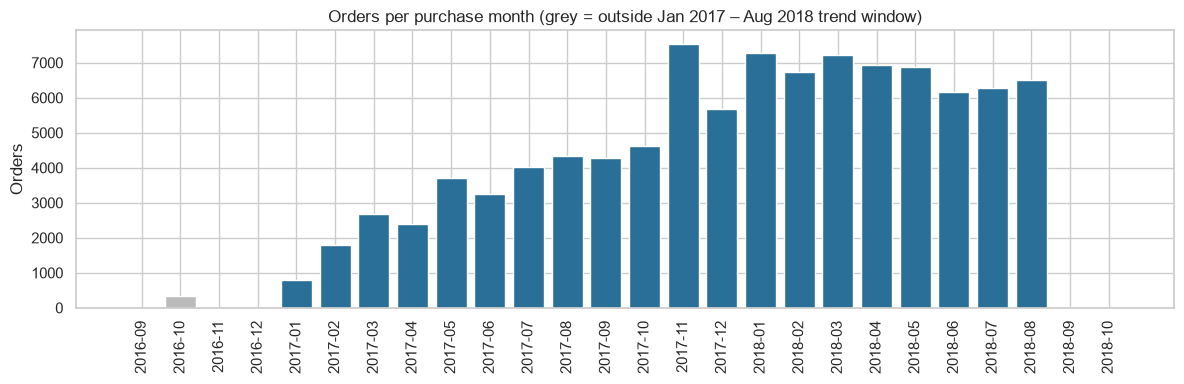

Orders before 2017: 329 | Nov 2016: 0 | from Sep 2018: 20


In [7]:
monthly = orders.groupby(orders["order_purchase_timestamp"].dt.to_period("M")).size()
monthly = monthly.reindex(pd.period_range(monthly.index.min(), monthly.index.max(), freq="M"), fill_value=0)
in_window = (monthly.index >= pd.Period("2017-01", "M")) & (monthly.index <= pd.Period("2018-08", "M"))

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly.index.astype(str), monthly.values, color=["#2a6f97" if w else "#bbbbbb" for w in in_window])
ax.set(title="Orders per purchase month (grey = outside Jan 2017 – Aug 2018 trend window)",
       xlabel=None, ylabel="Orders")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

print("Orders before 2017:", int(monthly[monthly.index < pd.Period("2017-01", "M")].sum()),
      "| Nov 2016:", int(monthly[pd.Period("2016-11", "M")]),
      "| from Sep 2018:", int(monthly[monthly.index >= pd.Period("2018-09", "M")].sum()))

## 6. Review scores

All review rows as loaded (duplicates included; latest-review-per-order logic comes in Phase 2).

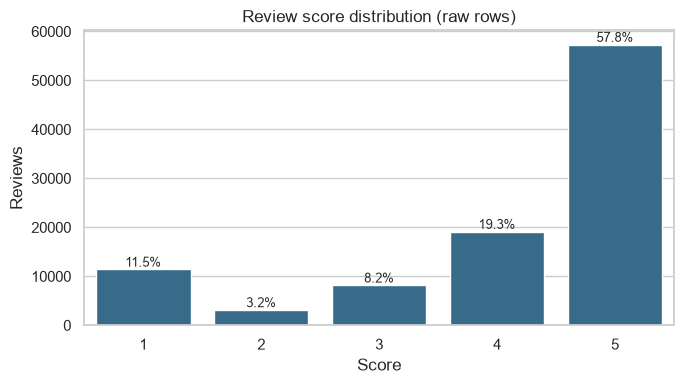

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(x=reviews["review_score"].astype(int), color="#2a6f97", ax=ax)
ax.set(title="Review score distribution (raw rows)", xlabel="Score", ylabel="Reviews")
for p in ax.patches:
    ax.annotate(f"{p.get_height() / len(reviews):.1%}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## 7. Delivery time

Actual days from purchase to customer delivery vs the promised (estimated) days, for delivered orders
with a delivered date. Clipped at 60 days for readability (the tail is listed below).

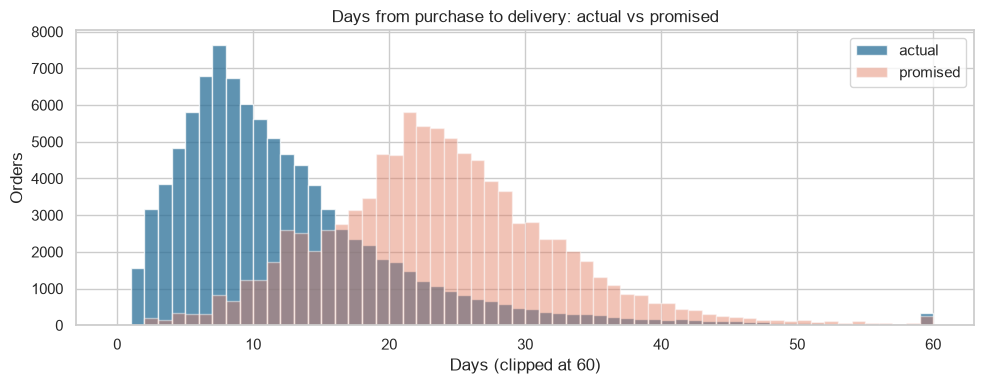

Median actual 10.2 d vs promised 23.2 d; 306 orders took > 60 d (max 210 d)


In [9]:
dlv = orders[(orders["order_status"] == "delivered") & orders["order_delivered_customer_date"].notna()].copy()
dlv["delivery_days"] = (dlv["order_delivered_customer_date"] - dlv["order_purchase_timestamp"]).dt.total_seconds() / 86400
dlv["promised_days"] = (dlv["order_estimated_delivery_date"] - dlv["order_purchase_timestamp"]).dt.total_seconds() / 86400

fig, ax = plt.subplots(figsize=(10, 4))
bins = range(0, 61)
ax.hist(dlv["delivery_days"].clip(upper=60), bins=bins, alpha=0.75, label="actual", color="#2a6f97")
ax.hist(dlv["promised_days"].clip(upper=60), bins=bins, alpha=0.45, label="promised", color="#e07a5f")
ax.set(title="Days from purchase to delivery: actual vs promised", xlabel="Days (clipped at 60)", ylabel="Orders")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Median actual {dlv['delivery_days'].median():.1f} d vs promised {dlv['promised_days'].median():.1f} d; "
      f"{(dlv['delivery_days'] > 60).sum()} orders took > 60 d (max {dlv['delivery_days'].max():.0f} d)")

## 8. Data-quality quirks

Every number here is quoted in `docs/data_quality_log.md`. `late` uses the project definition:
`delivered::date > estimated::date` on delivered orders with a delivered date.

In [10]:
cust, rv, prod, pay, geo, tr = (raw[t] for t in
    ["customers", "order_reviews", "products", "order_payments", "geolocation", "product_category_name_translation"])
oid = orders["order_id"]
late = dlv["order_delivered_customer_date"].dt.normalize() > dlv["order_estimated_delivery_date"].dt.normalize()

quirks = {
    "distinct customer_unique_id (of 99,441 customer_id)": cust["customer_unique_id"].nunique(),
    "review rows whose review_id repeats (extra copies)": int(rv["review_id"].duplicated().sum()),
    "distinct review_id values that repeat": rv.loc[rv["review_id"].duplicated(), "review_id"].nunique(),
    "orders with > 1 review": int((rv.groupby("order_id").size() > 1).sum()),
    "orders with no review": int((~oid.isin(rv["order_id"])).sum()),
    "reviews with comment message (%)": round(rv["review_comment_message"].notna().mean() * 100, 1),
    "product categories (non-null, distinct)": prod["product_category_name"].nunique(),
    "products with null category": int(prod["product_category_name"].isna().sum()),
    "products missing weight/dimensions": int(prod["product_weight_g"].isna().sum()),
    "categories missing a translation": ", ".join(sorted(set(prod["product_category_name"].dropna())
                                                         - set(tr["product_category_name"]))),
    "geolocation distinct zip prefixes": geo["geolocation_zip_code_prefix"].nunique(),
    "geolocation exact-duplicate rows": int(geo.duplicated().sum()),
    "geolocation points outside Brazil lat [-34, 6]": int((~geo["geolocation_lat"].astype(float).between(-34, 6)).sum()),
    "delivered orders with no delivered date": int(((orders["order_status"] == "delivered")
                                                    & orders["order_delivered_customer_date"].isna()).sum()),
    "orders with null approved_at": int(orders["order_approved_at"].isna().sum()),
    "orders handed to carrier before purchase": int((orders["order_delivered_carrier_date"]
                                                     < orders["order_purchase_timestamp"]).sum()),
    "orders delivered before purchase": int((orders["order_delivered_customer_date"]
                                             < orders["order_purchase_timestamp"]).sum()),
    "orders with no items": int((~oid.isin(items["order_id"])).sum()),
    "orders with no payment": int((~oid.isin(pay["order_id"])).sum()),
    "orders with > 1 seller": int((items.groupby("order_id")["seller_id"].nunique() > 1).sum()),
    "max items in one order": int(items["order_item_id"].astype(int).max()),
    "items with shipping_limit_date after 2018": int((items["shipping_limit_date"] > "2018-12-31").sum()),
    "items with freight_value = 0": int((items["freight_value"].astype(float) == 0).sum()),
    "payments with payment_value = 0": int((pay["payment_value"].astype(float) == 0).sum()),
    "payments with payment_type = not_defined": int((pay["payment_type"] == "not_defined").sum()),
    "payments with 0 installments": int((pay["payment_installments"] == "0").sum()),
    "customer states (UF)": cust["customer_state"].nunique(),
    "customer zip prefixes with a leading zero": int(cust["customer_zip_code_prefix"].str.startswith("0").sum()),
    "late-delivery share (%)": round(late.mean() * 100, 2),
    "late orders / delivered orders with date": f"{int(late.sum()):,} / {len(dlv):,}",
}
pd.Series(quirks, name="value").to_frame()

,value
"distinct customer_unique_id (of 99,441 customer_id)",96096
review rows whose review_id repeats (extra copies),814
distinct review_id values that repeat,789
orders with > 1 review,547
orders with no review,768
reviews with comment message (%),41.3
"product categories (non-null, distinct)",73
products with null category,610
products missing weight/dimensions,2
categories missing a translation,"pc_gamer, portateis_cozinha_e_preparadores_de_..."


In [11]:
print("Order status counts:")
print(orders["order_status"].value_counts().to_string())
print()
print("Payment type counts:")
print(pay["payment_type"].value_counts().to_string())

Order status counts:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2

Payment type counts:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3


## Takeaways for Phase 2

- `customer_id` is per order; the person is `customer_unique_id` (96,096). `dim_customer` uses it.
- Reviews need **latest per order** (`int_order_reviews_latest`), and the `review_id` uniqueness test is
  expected to warn. Note dbt's `unique` test returns one row per duplicated *value* (789), not per extra
  row (814).
- Two untranslated categories → `category_translation_patch.csv` seed; 610 null categories → `'unknown'`.
- Geolocation must be aggregated per zip prefix (19,015) before any join.
- Trend window Jan 2017 – Aug 2018; edge months are partial.

# 01 · Part 2: memo-ready charts

Reads the dbt marts (`marts.*`), so it needs Postgres; part 1 above runs without it. One shared style
(`scripts/plot_style.py`: blue = baseline / on time, orange = late / highlight, grey = context), one message per
chart in the title, saved at 160 dpi to `docs/img/` for the insight memo and README. The dose-response chart
(`one_star_by_days_late.png`) is saved by `02_late_delivery_stats.ipynb`.

In [12]:
import numpy as np
from matplotlib.ticker import FuncFormatter, PercentFormatter

from scripts.plot_style import BLUE, GREY, INK_2, ORANGE, apply_style, save_fig

apply_style()
assert db.is_reachable(), "Part 2 reads the dbt marts: start Postgres and run `dbt build` first"
brl_m = FuncFormatter(lambda v, _: f"R${v / 1e6:.1f}M")

## 9. Growth: monthly orders and GMV (trend window Jan 2017 – Aug 2018)

Two panels on a shared time axis instead of one dual-axis chart. GMV = delivered item price (no freight).

Jan-Aug orders: 22,968 (2017) -> 53,991 (2018), +135%


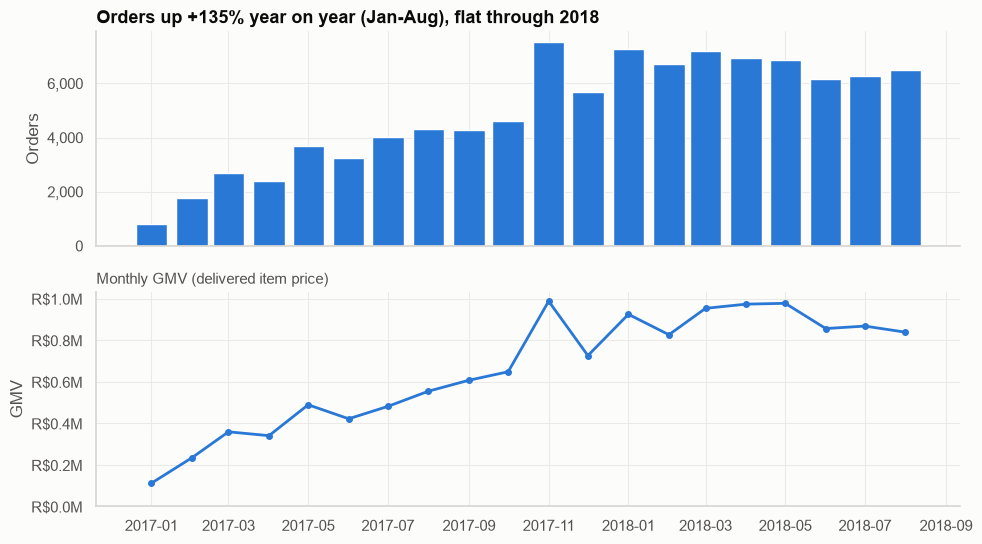

In [13]:
kpi = db.read_sql("select * from marts.kpi_monthly order by month_start")
kpi["month_start"] = pd.to_datetime(kpi["month_start"])
kpi[["gmv"]] = kpi[["gmv"]].astype(float)

jan_aug = kpi[kpi["month_start"].dt.month <= 8].groupby(kpi["month_start"].dt.year)["orders"].sum()
growth = jan_aug[2018] / jan_aug[2017] - 1

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True)
ax1.bar(kpi["month_start"], kpi["orders"], width=24, color=BLUE)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax1.set(title=f"Orders up {growth:+.0%} year on year (Jan-Aug), flat through 2018", ylabel="Orders")
ax2.plot(kpi["month_start"], kpi["gmv"], color=BLUE, marker="o", markersize=4)
ax2.yaxis.set_major_formatter(brl_m)
ax2.set(ylabel="GMV", ylim=(0, None))
ax2.set_title("Monthly GMV (delivered item price)", fontsize=11, fontweight="normal", color=INK_2)
print(f"Jan-Aug orders: {jan_aug[2017]:,} (2017) -> {jan_aug[2018]:,} (2018), {growth:+.0%}")
plt.tight_layout()
save_fig(fig, "monthly_orders_gmv")
plt.show()

## 10. Delivery: late share by customer state

Late = delivered after the promised date (delivered orders with a delivered date). Northeast states in orange.

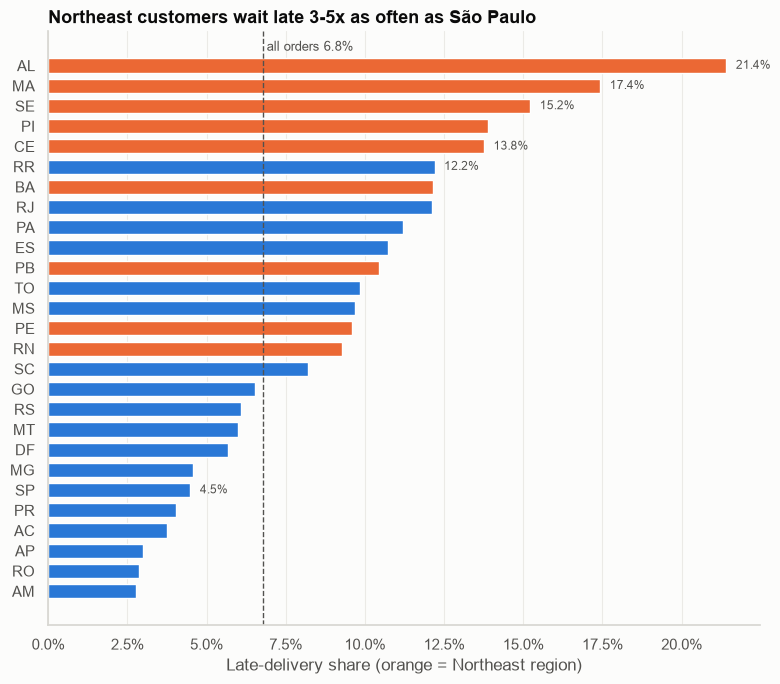

,customer_state,customer_region,orders,late_rate
1,AL,Northeast,397,0.2141
9,MA,Northeast,717,0.1743
24,SE,Northeast,335,0.1522
16,PI,Northeast,476,0.1387
5,CE,Northeast,1279,0.1376


In [14]:
st = db.read_sql("select * from marts.freight_by_state").astype({"late_rate": float, "freight_share": float})
st = st.sort_values("late_rate")
overall_late = db.read_sql("select avg(is_late::int) as r from marts.fact_orders where is_late is not null")["r"].iloc[0]

fig, ax = plt.subplots(figsize=(8, 7))
colors = [ORANGE if r == "Northeast" else BLUE for r in st["customer_region"]]
ax.barh(st["customer_state"], st["late_rate"], color=colors, height=0.7)
ax.axvline(overall_late, color=INK_2, lw=1, ls="--")
ax.text(overall_late, len(st) - 0.4, f" all orders {overall_late:.1%}", fontsize=9, color=INK_2, va="bottom")
for y, (rate, state) in enumerate(zip(st["late_rate"], st["customer_state"], strict=True)):
    if state in ("AL", "MA", "SE", "SP", "RR", "CE"):
        ax.text(rate + 0.003, y, f"{rate:.1%}", va="center", fontsize=8.5, color=INK_2)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set(title="Northeast customers wait late 3-5x as often as São Paulo",
       xlabel="Late-delivery share (orange = Northeast region)", ylabel=None)
ax.grid(axis="y", visible=False)
plt.tight_layout()
save_fig(fig, "late_share_by_state")
plt.show()
st.sort_values("late_rate", ascending=False).head(5)[["customer_state", "customer_region", "orders", "late_rate"]]

## 11. Satisfaction: review distribution, late vs on time

Latest review per order, delivered orders with a delivered date. 100% stacked so the two groups compare
despite a 14:1 size difference.

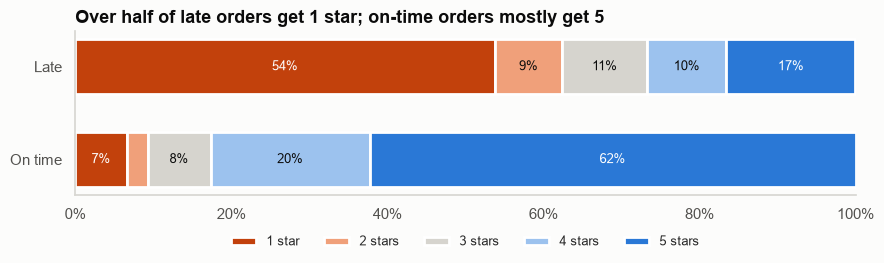

In [15]:
rv_dist = db.read_sql("""
    select case when is_late then 'Late' else 'On time' end as delivery, review_score, count(*) as orders
    from marts.fact_orders
    where is_late is not null and review_score is not null
    group by 1, 2
""")
share = rv_dist.pivot(index="delivery", columns="review_score", values="orders")
share = share.div(share.sum(axis=1), axis=0).loc[["Late", "On time"]]

# Diverging: 1-2 stars warm, 3 neutral grey, 4-5 cool.
score_colors = {1: "#c2410c", 2: "#f0a07a", 3: "#d6d4ce", 4: "#9cc2ee", 5: "#2a78d6"}
fig, ax = plt.subplots(figsize=(9, 2.9))
left = np.zeros(len(share))
for score in [1, 2, 3, 4, 5]:
    vals = share[score].values
    ax.barh(share.index, vals, left=left, color=score_colors[score], edgecolor="white", linewidth=2,
            label=f"{score} star" + ("s" if score > 1 else ""), height=0.6)
    for y, (v, x0) in enumerate(zip(vals, left, strict=True)):
        if v >= 0.06:
            ax.text(x0 + v / 2, y, f"{v:.0%}", ha="center", va="center", fontsize=9,
                    color="white" if score in (1, 5) else "#0b0b0b")
    left += vals
ax.invert_yaxis()
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set(title="Over half of late orders get 1 star; on-time orders mostly get 5", xlim=(0, 1))
ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.18), fontsize=9)
ax.grid(False)
plt.tight_layout()
save_fig(fig, "review_distribution_late_vs_on_time")
plt.show()

## 12. Category Pareto

Share of delivered item GMV by category (bars) and cumulative share (line), both on one percentage axis.
Null category excluded (73 categories); A-class categories (needed to reach 80%) in blue.

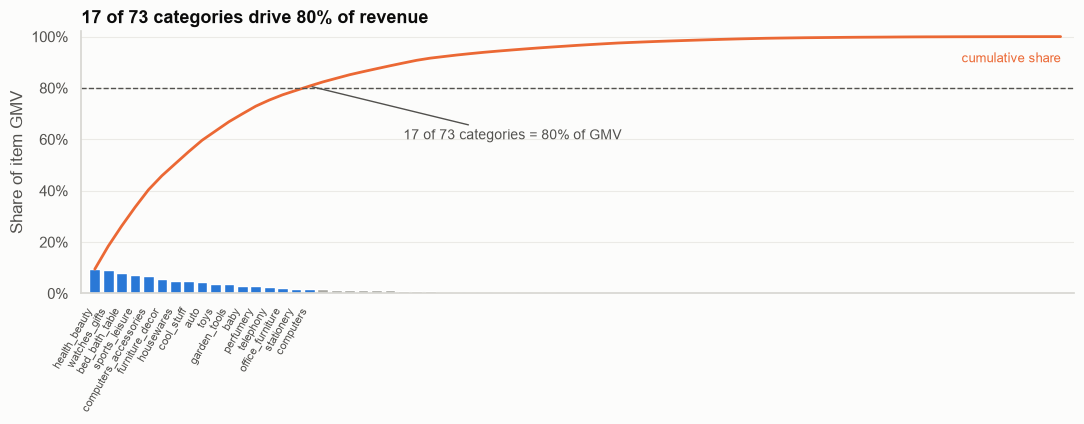

In [16]:
cp = db.read_sql("select * from marts.category_pareto order by gmv_rank").astype(
    {"gmv_share": float, "cum_share": float})
n_a = int((cp["abc_class"] == "A").sum())

fig, ax = plt.subplots(figsize=(11, 4.4))
x = np.arange(len(cp))
ax.bar(x, cp["gmv_share"], color=[BLUE if c == "A" else GREY for c in cp["abc_class"]], width=0.8)
ax.plot(x, cp["cum_share"], color=ORANGE, lw=2)
ax.axhline(0.8, color=INK_2, lw=1, ls="--")
ax.annotate(f"{n_a} of {len(cp)} categories = 80% of GMV", (n_a - 1, cp["cum_share"].iloc[n_a - 1]),
            xytext=(n_a + 6, 0.6), fontsize=10, color=INK_2, arrowprops={"arrowstyle": "-", "color": INK_2})
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xticks(x[:n_a], cp["category_en"].iloc[:n_a], rotation=60, ha="right", fontsize=8)
ax.set(title=f"{n_a} of {len(cp)} categories drive 80% of revenue", ylabel="Share of item GMV",
       xlim=(-1, len(cp)), ylim=(0, 1.02))
ax.grid(axis="x", visible=False)
ax.text(len(cp) - 1, 0.9, "cumulative share", color=ORANGE, ha="right", fontsize=9)
plt.tight_layout()
save_fig(fig, "category_pareto")
plt.show()

## Takeaways for the memo (Phase 6)

- Volume grew fast through 2017 (+135% Jan–Aug YoY) and flattened in 2018; the trend window avoids the partial
  edge months.
- Late delivery is a regional problem: the Northeast runs at several times São Paulo's late share.
- Lateness reshapes the whole review distribution, not only the 1-star tail (stats in `02_late_delivery_stats`).
- Revenue is concentrated: a minority of categories carry 80% of GMV.

Charts in `docs/img/`: `monthly_orders_gmv.png`, `late_share_by_state.png`,
`review_distribution_late_vs_on_time.png`, `category_pareto.png`, `one_star_by_days_late.png`.